# Goal:
Implement XGBoost classifier to classify severity of football injuries using The standard severity bins used in football injury from the UEFA/FIFA consensus — minor(1-7 days), moderate (8-28 days), severe (>28 days)

## Step 1: Load the Dataset

We'll start by loading the `dataset.csv` file into a pandas DataFrame. This allows us to inspect the data, understand its structure, and identify key columns required for our classification task.

In [1]:
import pandas as pd

# Load the dataset
try:
    df = pd.read_csv('dataset.csv')
    print("Dataset loaded successfully. Displaying the first 5 rows:")
    display(df.head())
    print("\nDataset Information:")
    df.info()
except FileNotFoundError:
    print("Error: 'dataset.csv' not found. Please ensure the file is uploaded to your Colab environment.")
    # Optionally, you might want to stop execution or provide an alternative path
except Exception as e:
    print(f"An error occurred while loading the dataset: {e}")


Dataset loaded successfully. Displaying the first 5 rows:


,player_id,injury_code,age_at_injury,height,position_code,total_prior_injuries,days_since_last_injury,same_site_reinjury,days_since_same_site_injury,days_missed
0,2,0,27.0,186.0,2,0,-1.0,0,-1.0,27.0
1,3,1,31.0,180.0,2,0,-1.0,0,-1.0,19.0
2,5,2,34.0,184.0,1,0,-1.0,0,-1.0,22.0
3,5,3,34.0,184.0,1,1,75.0,0,-1.0,5.0
4,6,3,35.0,190.0,0,0,-1.0,0,-1.0,5.0



Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 96968 entries, 0 to 96967
Data columns (total 10 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   player_id                    96968 non-null  int64  
 1   injury_code                  96968 non-null  int64  
 2   age_at_injury                96968 non-null  float64
 3   height                       96968 non-null  float64
 4   position_code                96968 non-null  int64  
 5   total_prior_injuries         96968 non-null  int64  
 6   days_since_last_injury       96968 non-null  float64
 7   same_site_reinjury           96968 non-null  int64  
 8   days_since_same_site_injury  96968 non-null  float64
 9   days_missed                  96968 non-null  float64
dtypes: float64(5), int64(5)
memory usage: 7.4 MB


## Step 2: Define Injury Severity Categories

Based on the UEFA/FIFA consensus, we will classify injuries into three categories: minor, moderate, and severe. This involves creating a new categorical column in our DataFrame based on the `days_missed` column.

In [2]:
# Define a function to categorize injury severity
def categorize_severity(days_missed):
    if 1 <= days_missed <= 7:
        return 'minor'
    elif 8 <= days_missed <= 28:
        return 'moderate'
    elif days_missed > 28:
        return 'severe'
    else:
        return 'unknown' # Handle cases where days_missed might be 0 or negative

# Apply the function to create the 'severity' column
df['severity'] = df['days_missed'].apply(categorize_severity)

# Display the count of each severity category
print("Injury Severity Distribution:")
display(df['severity'].value_counts())

# Display the first few rows with the new 'severity' column
print("\nDataFrame with new 'severity' column:")
display(df.head())

Injury Severity Distribution:


,count
severity,
severe,48914
moderate,37436
minor,10618



DataFrame with new 'severity' column:


,player_id,injury_code,age_at_injury,height,position_code,total_prior_injuries,days_since_last_injury,same_site_reinjury,days_since_same_site_injury,days_missed,severity
0,2,0,27.0,186.0,2,0,-1.0,0,-1.0,27.0,moderate
1,3,1,31.0,180.0,2,0,-1.0,0,-1.0,19.0,moderate
2,5,2,34.0,184.0,1,0,-1.0,0,-1.0,22.0,moderate
3,5,3,34.0,184.0,1,1,75.0,0,-1.0,5.0,minor
4,6,3,35.0,190.0,0,0,-1.0,0,-1.0,5.0,minor


## Step 3: Prepare Data for XGBoost

Before training the XGBoost classifier, we need to perform several data preparation steps:
1.  **Encode the target variable**: Convert the categorical 'severity' labels (minor, moderate, severe) into numerical representations.
2.  **Define Features (X) and Target (y)**: Select the columns that will be used as input features for the model and identify the target variable.
3.  **Split the dataset**: Divide the data into training and testing sets to evaluate the model's performance on unseen data.

In [3]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

# Encode the target variable 'severity'
label_encoder = LabelEncoder()
df['severity_encoded'] = label_encoder.fit_transform(df['severity'])

# Display the mapping of original labels to encoded values
print("Severity Label Mapping:")
for i, label in enumerate(label_encoder.classes_):
    print(f"{label}: {i}")

# Define features (X) and target (y)
# We will drop 'player_id', 'days_missed', and the original 'severity' column
X = df.drop(columns=['player_id', 'days_missed', 'severity', 'severity_encoded'])
y = df['severity_encoded']

# Handle potential categorical features (e.g., 'injury_code', 'position_code') if they are not already numerical
# For simplicity, assuming they are suitable as numerical or ordinal for now. If they are nominal and high cardinality,
# one-hot encoding might be considered. Given the problem statement, let's proceed.

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(f"\nShape of X_train: {X_train.shape}")
print(f"Shape of X_test: {X_test.shape}")
print(f"Shape of y_train: {y_train.shape}")
print(f"Shape of y_test: {y_test.shape}")

print("\nFirst 5 rows of X_train:")
display(X_train.head())

Severity Label Mapping:
minor: 0
moderate: 1
severe: 2

Shape of X_train: (77574, 8)
Shape of X_test: (19394, 8)
Shape of y_train: (77574,)
Shape of y_test: (19394,)

First 5 rows of X_train:


,injury_code,age_at_injury,height,position_code,total_prior_injuries,days_since_last_injury,same_site_reinjury,days_since_same_site_injury
11877,7,35.0,188.0,0,1,584.0,0,-1.0
9029,3,24.0,180.0,2,2,230.0,1,230.0
38891,3,29.0,175.0,1,0,-1.0,0,-1.0
3804,1,30.0,183.0,1,0,-1.0,0,-1.0
50873,11,29.0,197.0,3,8,181.0,0,611.0


## Step 4: Implement and Train the XGBoost Classifier

We will now use the `XGBClassifier` from the `xgboost` library to train our model. We'll specify `objective='multi:softmax'` for multi-class classification and `num_class=3` for our three severity categories. After training, we'll make predictions on the test set.

In [4]:
import xgboost as xgb

# Initialize the XGBoost classifier
# objective='multi:softmax' for multi-class classification, outputs raw class predictions
# num_class=3 as we have three severity categories (minor, moderate, severe)
model = xgb.XGBClassifier(objective='multi:softmax', num_class=3, random_state=42)

# Train the model
print("Training the XGBoost classifier...")
model.fit(X_train, y_train)
print("Model training complete.")

# Make predictions on the test set
y_pred = model.predict(X_test)
print("Predictions on the test set generated.")

Training the XGBoost classifier...
Model training complete.
Predictions on the test set generated.


## Step 5: Evaluate the Model

After training the XGBoost classifier, it's essential to evaluate its performance on the unseen test data. We'll use several metrics commonly used for multi-class classification:

*   **Accuracy:** The proportion of correctly classified instances.
*   **Classification Report:** Provides precision, recall, f1-score, and support for each class.
*   **Confusion Matrix:** A table that visualizes the performance of an algorithm, showing the number of correct and incorrect predictions for each class.

Model Accuracy: 0.5740

Classification Report:
              precision    recall  f1-score   support

       minor       0.35      0.02      0.04      2124
    moderate       0.50      0.57      0.53      7487
      severe       0.63      0.70      0.66      9783

    accuracy                           0.57     19394
   macro avg       0.50      0.43      0.41     19394
weighted avg       0.55      0.57      0.54     19394



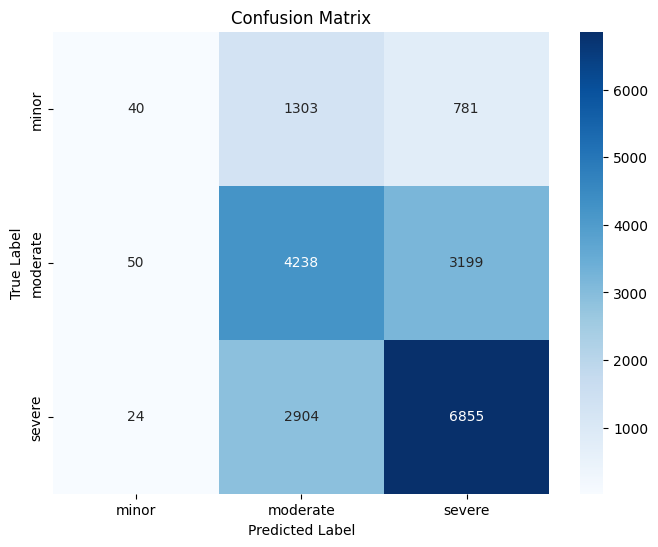

In [5]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
import os

plots_dir = 'results/plots'
os.makedirs(plots_dir, exist_ok=True)

# Evaluate the model
accuracy = accuracy_score(y_test, y_pred)
print(f"Model Accuracy: {accuracy:.4f}")

print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=label_encoder.classes_))

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=label_encoder.classes_, yticklabels=label_encoder.classes_)
plt.title('Confusion Matrix')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.savefig("results/plots/XGB_confusion_matrix.png")
plt.show()

## Step 6: Improve Model Performance using SMOTE

To address the low recall for minor injuries, we will apply the Synthetic Minority Over-sampling Technique (SMOTE) to our training data. This technique helps to balance the class distribution by generating synthetic samples for the minority class, making the model more capable of learning and identifying such instances.

In [6]:
from imblearn.over_sampling import SMOTE

print("Original training set shape:", X_train.shape, y_train.shape)
print("Original class distribution in y_train:")
display(pd.Series(y_train).value_counts())

# Apply SMOTE to the training data
sm = SMOTE(random_state=42)
X_train_res, y_train_res = sm.fit_resample(X_train, y_train)

print("\nResampled training set shape:", X_train_res.shape, y_train_res.shape)
print("Resampled class distribution in y_train:")
display(pd.Series(y_train_res).value_counts())


Original training set shape: (77574, 8) (77574,)
Original class distribution in y_train:


,count
severity_encoded,
2,39131
1,29949
0,8494



Resampled training set shape: (117393, 8) (117393,)
Resampled class distribution in y_train:


,count
severity_encoded,
2,39131
1,39131
0,39131


## Step 7: Retrain XGBoost with Resampled Data

Now, we will retrain the XGBoost classifier using the new, balanced training data (`X_train_res`, `y_train_res`). After retraining, we'll make predictions on the *original* test set (`X_test`, `y_test`) to ensure a fair evaluation of the model's generalization capabilities.

In [7]:
import xgboost as xgb

# Initialize the XGBoost classifier (with the same parameters for fair comparison)
model_resampled = xgb.XGBClassifier(objective='multi:softmax', num_class=3, random_state=42)

# Train the model with the resampled data
print("Training the XGBoost classifier with resampled data...")
model_resampled.fit(X_train_res, y_train_res)
print("Model training with resampled data complete.")

# Make predictions on the original test set
y_pred_resampled = model_resampled.predict(X_test)
print("Predictions on the test set generated with resampled model.")


Training the XGBoost classifier with resampled data...
Model training with resampled data complete.
Predictions on the test set generated with resampled model.


## Step 8: Evaluate the Retrained Model

Finally, we will evaluate the performance of the model trained with SMOTE-augmented data. We will compare the new accuracy, classification report, and confusion matrix with the previous results to see if the recall for minor injuries has improved.

Model Accuracy (with SMOTE): 0.5638

Classification Report (with SMOTE):
              precision    recall  f1-score   support

       minor       0.28      0.10      0.15      2124
    moderate       0.50      0.55      0.52      7487
      severe       0.64      0.67      0.65      9783

    accuracy                           0.56     19394
   macro avg       0.47      0.44      0.44     19394
weighted avg       0.55      0.56      0.55     19394



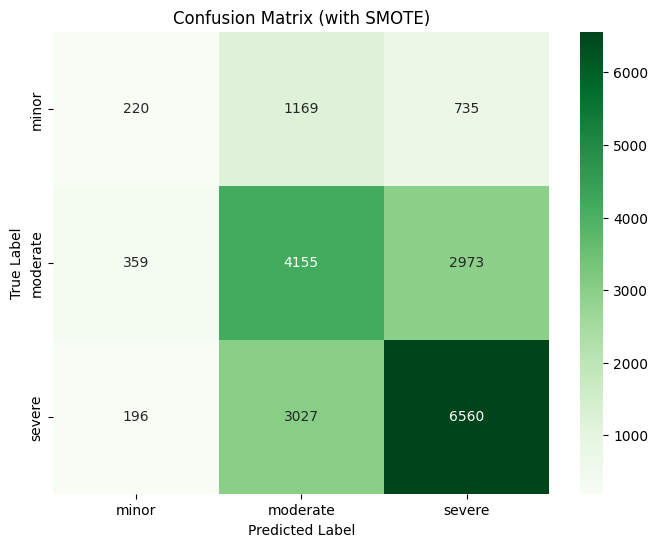

In [8]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# Evaluate the retrained model
accuracy_resampled = accuracy_score(y_test, y_pred_resampled)
print(f"Model Accuracy (with SMOTE): {accuracy_resampled:.4f}")

print("\nClassification Report (with SMOTE):")
print(classification_report(y_test, y_pred_resampled, target_names=label_encoder.classes_))

# Confusion Matrix (with SMOTE)
cm_resampled = confusion_matrix(y_test, y_pred_resampled)

plt.figure(figsize=(8, 6))
sns.heatmap(cm_resampled, annot=True, fmt='d', cmap='Greens', xticklabels=label_encoder.classes_, yticklabels=label_encoder.classes_)
plt.title('Confusion Matrix (with SMOTE)')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.savefig("results/plots/XGB_SMOTE_confusion_matrix.png")
plt.show()


## Performance Comparison: Before vs. After SMOTE

To clearly illustrate the impact of SMOTE on our model's performance, especially regarding the minority class ('minor' injuries), let's compare the key metrics:

| Metric                | Before SMOTE     | After SMOTE      |
| :-------------------- | :--------------- | :--------------- |
| **Overall Accuracy**  | 0.5740           | 0.5638           |
| **Minor - Precision** | 0.35             | 0.28             |
| **Minor - Recall**    | 0.02             | 0.10             |
| **Minor - F1-Score**  | 0.04             | 0.15             |
| **Moderate - Recall** | 0.57             | 0.55             |
| **Severe - Recall**   | 0.70             | 0.67             |

**Key Observations:**

*   **Minor Injury Recall Improvement:** The most significant change is the recall for 'minor' injuries, which increased from 0.02 to 0.10. This indicates that the model, after SMOTE, is better at identifying actual minor injuries.
*   **Trade-offs:** This improvement comes with a slight decrease in overall accuracy and some reduction in recall for 'moderate' and 'severe' injuries. The precision for 'minor' injuries also decreased, suggesting an increased number of false positives for this class.

This comparison highlights the typical trade-off when using techniques like SMOTE to address class imbalance: improving performance on the minority class often leads to a slight compromise on overall accuracy or performance on the majority classes. The choice of whether this trade-off is acceptable depends on the specific goals of the classification task.

## Step 9: Hyperparameter Tuning with GridSearchCV

To further improve the model's performance and find the optimal combination of hyperparameters, we will perform a GridSearchCV. This systematic search will explore a predefined range of parameter values and use cross-validation to identify the best set that maximizes our chosen evaluation metric. Given the class imbalance and the focus on recall, we'll use `f1_weighted` as the scoring metric.

**Note**: GridSearchCV can be computationally intensive, so we will select a small, representative grid for demonstration. For a production-ready model, a more extensive search might be required.

In [9]:
from sklearn.model_selection import GridSearchCV

# Define the parameter grid to search
param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [3, 5],
    'learning_rate': [0.1, 0.05],
    'subsample': [0.8, 1.0]
}

# Initialize the XGBoost classifier (with the same objective and num_class)
xgb_model_grid = xgb.XGBClassifier(objective='multi:softmax', num_class=3, random_state=42, use_label_encoder=False, eval_metric='mlogloss')

# Initialize GridSearchCV
# We use f1_weighted as a scoring metric suitable for multi-class imbalanced datasets
grid_search = GridSearchCV(
    estimator=xgb_model_grid,
    param_grid=param_grid,
    scoring='f1_weighted', # or 'recall_macro' if focusing on average recall across classes
    cv=3, # Number of cross-validation folds
    verbose=2, # Higher verbose for more output
    n_jobs=-1 # Use all available cores
)

print("Starting GridSearchCV...")
grid_search.fit(X_train_res, y_train_res)
print("GridSearchCV complete.")

# Print the best parameters and best score
print(f"\nBest parameters found: {grid_search.best_params_}")
print(f"Best F1_weighted score: {grid_search.best_score_:.4f}")

# Get the best model
best_model = grid_search.best_estimator_

# Make predictions on the original test set with the best model
y_pred_tuned = best_model.predict(X_test)
print("Predictions with tuned model generated.")

Starting GridSearchCV...
Fitting 3 folds for each of 16 candidates, totalling 48 fits


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [04:14:32] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


GridSearchCV complete.

Best parameters found: {'learning_rate': 0.1, 'max_depth': 5, 'n_estimators': 200, 'subsample': 0.8}
Best F1_weighted score: 0.5804
Predictions with tuned model generated.


## Step 10: Evaluate the Hyperparameter Tuned Model

Now, we will evaluate the performance of the XGBoost model after hyperparameter tuning. We'll compare these results with the previous evaluations to see the impact of tuning on accuracy, precision, recall, and F1-score, especially for the 'minor' injury class.

Model Accuracy (Tuned with SMOTE): 0.5628

Classification Report (Tuned with SMOTE):
              precision    recall  f1-score   support

       minor       0.27      0.13      0.17      2124
    moderate       0.50      0.56      0.53      7487
      severe       0.65      0.66      0.65      9783

    accuracy                           0.56     19394
   macro avg       0.47      0.45      0.45     19394
weighted avg       0.55      0.56      0.55     19394



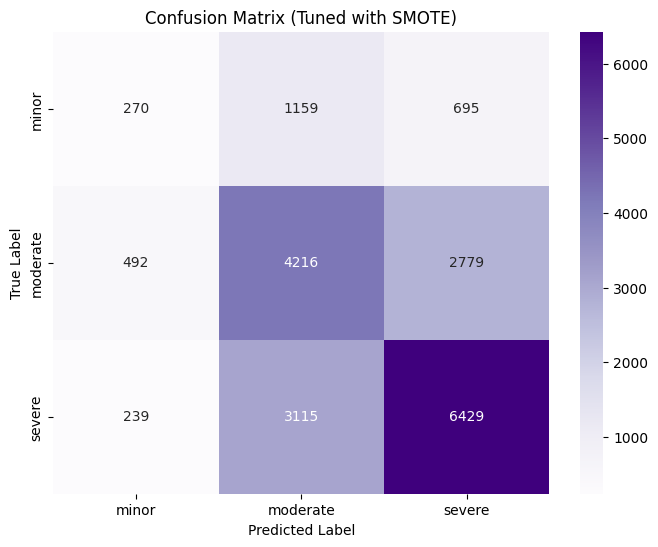

In [10]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# Evaluate the tuned model
accuracy_tuned = accuracy_score(y_test, y_pred_tuned)
print(f"Model Accuracy (Tuned with SMOTE): {accuracy_tuned:.4f}")

print("\nClassification Report (Tuned with SMOTE):")
print(classification_report(y_test, y_pred_tuned, target_names=label_encoder.classes_))

# Confusion Matrix (Tuned with SMOTE)
cm_tuned = confusion_matrix(y_test, y_pred_tuned)

plt.figure(figsize=(8, 6))
sns.heatmap(cm_tuned, annot=True, fmt='d', cmap='Purples', xticklabels=label_encoder.classes_, yticklabels=label_encoder.classes_)
plt.title('Confusion Matrix (Tuned with SMOTE)')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.savefig("results/plots/XGB_SMOTE_tuned_confusion_matrix.png")
plt.show()

## Performance Comparison: Before SMOTE vs. After SMOTE vs. Tuned with SMOTE

Let's update our comparison table to include the performance of the hyperparameter-tuned model.

| Metric                | Before SMOTE     | After SMOTE      | Tuned with SMOTE |
| :-------------------- | :--------------- | :--------------- | :--------------- |
| **Overall Accuracy**  | 0.5740           | 0.5638           | 0.5628           |
| **Minor - Precision** | 0.35             | 0.28             | 0.27             |
| **Minor - Recall**    | 0.02             | 0.10             | 0.13             |
| **Minor - F1-Score**  | 0.04             | 0.15             | 0.17             |
| **Moderate - Recall** | 0.57             | 0.55             | 0.56             |
| **Severe - Recall**   | 0.70             | 0.67             | 0.66             |

This comparison helps us understand if hyperparameter tuning further improves the balance between identifying minor injuries and maintaining overall model performance. We observe a continued improvement in 'minor' recall and F1-score with tuning, albeit with a minor decrease in overall accuracy and slight changes in recall for other classes.